# Phase 5: RFM Analysis

**Netflix Prize Data Mining Project — Person E (Yuanyuan)**

This notebook implements **RFM (Recency, Frequency, Monetary)** analysis on Netflix rating data to segment users into meaningful behavioral groups. The objective is to identify distinct engagement patterns and translate them into **actionable customer strategies**.

RFM analysis is a widely used customer analytics framework in marketing and CRM. It evaluates customers along three dimensions:

- **Recency** – how recently a user interacted with the platform
- **Frequency** – how often the user interacts
- **Monetary value** – the value or quality associated with the interaction

By combining these three signals, we can categorize users into interpretable segments such as **Best Customers**, **Loyal Customers**, **At Risk**, and **Lost Customers**.

This analysis follows the **course framework for customer segmentation** and aligns with the project's multi-person structure:

1. **Construct RFM metrics** from user rating histories.
2. **Assign quintile scores** to normalize Recency, Frequency, and Monetary values.
3. **Segment users** using rule-based RFM patterns.
4. **Interpret segment behavior** and propose marketing strategies.
5. **Compare RFM segments with clustering results** from Person D to validate behavioral patterns.

The resulting segmentation helps answer key business questions:

- Which users are the most valuable and should be prioritized for retention?
- Which users show signs of disengagement and require intervention?
- How can different segments be targeted with tailored marketing strategies?

## Imports & Paths

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# For 3D scatter and treemap
import plotly.express as px
import plotly.graph_objects as go

# Project paths (same convention as 01_data_loading, 04_clustering)
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if (cwd.parent / "data").exists() else cwd
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "05_rfm_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLUSTERING_DIR = PROJECT_ROOT / "outputs" / "04_clustering"

RATINGS_PATH = DATA_DIR / "ratings.parquet"
ratings = pd.read_parquet(RATINGS_PATH)
if not pd.api.types.is_datetime64_any_dtype(ratings["Date"]):
    ratings["Date"] = pd.to_datetime(ratings["Date"])
print("Ratings:", f"{len(ratings):,}", "rows. Columns:", ratings.columns.tolist())
print("Date range:", ratings["Date"].min(), "to", ratings["Date"].max())
print("Unique users:", ratings["CustomerID"].nunique(), "| Unique movies:", ratings["MovieID"].nunique())

Ratings: 100,480,507 rows. Columns: ['MovieID', 'CustomerID', 'Rating', 'Date', 'YearOfRelease', 'Title', 'Year', 'Month', 'DayOfWeek']
Date range: 1999-11-11 00:00:00 to 2005-12-31 00:00:00
Unique users: 480189 | Unique movies: 17770


## Section 5.1 RFM Metric Definitions

RFM analysis summarizes user engagement using three interpretable behavioral signals: **Recency**, **Frequency**, and **Monetary value**.

In traditional retail settings, these metrics measure purchase recency, purchase frequency, and spending. Since our dataset contains **user ratings instead of transactions**, we adapt the definitions accordingly.

The benchmark date is **2005-12-31**, which corresponds to the end of the dataset period and serves as the reference point for calculating recency.

| Metric | Conceptual definition | Implementation in Netflix dataset |
|------|------|------|
| **Recency (R)** | How recently a customer interacted with the service | Number of days since the user's **most recent rating**, measured relative to 2005-12-31 |
| **Frequency (F)** | How frequently a customer interacts | Total **number of ratings** submitted by the user |
| **Monetary (M)** | Value contributed by the customer | Average rating score given by the user, used as a proxy for engagement quality |

Interpretation:

- **Lower Recency values indicate more recent activity**, which typically reflects higher engagement.
- **Higher Frequency values indicate heavier platform usage.**
- **Higher Monetary values suggest more positive viewing experiences.**

Together, these metrics provide a concise yet informative representation of user behavior.

In [2]:
# Benchmark date: 2005-12-31 (as per project spec)
REFERENCE_DATE = pd.Timestamp("2005-12-31")

# Aggregate per user: last rating date, count, mean rating
user_agg = ratings.groupby("CustomerID").agg(
    last_date=("Date", "max"),
    F=("Rating", "count"),
    M=("Rating", "mean"),
).reset_index()

# R = days between last rating and 2005-12-31 (lower = more recent)
user_agg["R_days"] = (REFERENCE_DATE - user_agg["last_date"]).dt.days
user_agg["R"] = user_agg["R_days"].astype(int)

# Keep R, F, M for RFM; drop last_date after we have R
rfm = user_agg[["CustomerID", "R", "F", "M"]].copy()
print("RFM metrics (raw) — sample and summary:")
display(rfm.head(10))
rfm.describe().round(2)

RFM metrics (raw) — sample and summary:


,CustomerID,R,F,M
0,6,27,626,3.418530
1,7,34,881,4.011351
2,8,128,98,4.214286
3,10,67,260,3.392308
4,25,13,27,3.481481
5,33,98,36,3.750000
6,42,3,128,3.921875
7,59,101,157,3.707006
8,79,46,796,3.548995
9,83,77,32,3.968750


,CustomerID,R,F,M
count,480189.00,480189.00,480189.00,480189.00
mean,1323438.88,114.18,209.25,3.67
std,765211.63,153.60,302.34,0.47
min,6.00,0.00,1.00,1.00
25%,659122.00,17.00,39.00,3.38
50%,1322528.00,54.00,96.00,3.68
75%,1986118.00,159.00,259.00,3.98
max,2649429.00,2185.00,17653.00,5.00


## Section 5.2 Quintile Scoring and User Segmentation

### 5.2.1 Quintile Scoring

Because the raw R, F, and M values are measured on different scales, we convert them into **quintile scores** (1–5). This transformation standardizes the metrics and makes them comparable across users.

Each metric is divided into five equally sized groups:

- **Score 1** → lowest 20%
- **Score 5** → highest 20%

The scoring rules are defined so that **higher scores always indicate more valuable customers**:

- **R_score**: Based on the *inverse of recency* (more recent activity receives higher scores).
- **F_score**: Users with higher rating counts receive higher scores.
- **M_score**: Users with higher average ratings receive higher scores.

This normalization step ensures that no single metric dominates the segmentation.

In [3]:
# Quintile labels 1–5 (same as pd.qcut with 5 bins)
def quintile_score(series, ascending=True):
    """Return quintile rank 1–5. ascending=True: higher value -> higher score (e.g. F, M)."""
    return pd.qcut(series.rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# R: lower R_days = more recent = better -> higher score for more recent (rank by -R)
rfm["R_score"] = quintile_score(-rfm["R"], ascending=True)
rfm["F_score"] = quintile_score(rfm["F"], ascending=True)
rfm["M_score"] = quintile_score(rfm["M"], ascending=True)

# Composite RFM score: sum of R_score, F_score, M_score (range 3–15)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

print("Quintile score distributions:")
display(rfm[["R_score", "F_score", "M_score", "RFM_score"]].describe())
rfm.head(10)

Quintile score distributions:


,R_score,F_score,M_score,RFM_score
count,480189.000000,480189.000000,480189.000000,480189.000000
mean,3.000000,3.000000,3.000000,9.000000
std,1.414217,1.414217,1.414217,2.647457
min,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,2.000000,7.000000
50%,3.000000,3.000000,3.000000,9.000000
75%,4.000000,4.000000,4.000000,11.000000
max,5.000000,5.000000,5.000000,15.000000


,CustomerID,R,F,M,R_score,F_score,M_score,RFM_score
0,6,27,626,3.418530,4,5,2,11
1,7,34,881,4.011351,3,5,4,12
2,8,128,98,4.214286,2,3,5,10
3,10,67,260,3.392308,3,4,2,9
4,25,13,27,3.481481,4,1,2,7
5,33,98,36,3.750000,2,2,3,7
6,42,3,128,3.921875,5,3,4,12
7,59,101,157,3.707006,2,4,3,9
8,79,46,796,3.548995,3,5,2,10
9,83,77,32,3.968750,3,2,4,9


### 5.2.2 Composite RFM Score and Segment Assignment

After computing quintile scores for each metric, we construct a **composite RFM score**:

$$
RFM\_score = R\_score + F\_score + M\_score
$$

The resulting score ranges from **3 to 15**, where larger values represent more engaged and valuable users.

Users are then assigned to **behavioral segments** based on combinations of R, F, and M scores. These segments follow common patterns used in marketing analytics.

| Segment | RFM Pattern | Criteria | Interpretation |
|------|------|------|------|
| **Best Customers** | 444+ | High R, F, M | Highly engaged users who interact frequently and recently |
| **Loyal Customers** | X4X | High frequency and value | Regular users with stable engagement |
| **Big Spenders** | XX4 | High monetary value | Users who consistently give high ratings |
| **At Risk** | 213 | Low recency but moderate engagement | Previously active users who have recently disengaged |
| **Lost Customers** | 122 | Low recency and engagement | Users unlikely to return without intervention |
| **Lost Cheap Customers** | 111 | Lowest engagement | Minimal interaction with the platform |

Segmenting users in this way allows us to move from raw behavioral metrics to **interpretable strategic groups**.

In [4]:
def assign_rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Best Customers"
    if r >= 3 and f >= 4 and m >= 4:
        return "Loyal Customers"
    if m >= 4:
        return "Big Spenders"
    if r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    if r <= 2 and f <= 2 and m <= 2:
        return "Lost Cheap Customers"
    if r <= 2:
        return "Lost Customers"
    if r >= 4 and m >= 4 and f <= 3:
        return "Potential Loyal"
    if r >= 4 and m <= 2:
        return "Need Attention"
    if r <= 2 and f >= 3:
        return "Hibernating"
    return "Others"

rfm["segment"] = rfm.apply(assign_rfm_segment, axis=1)
segment_counts = rfm["segment"].value_counts().sort_values(ascending=False)
n_users = len(rfm)
print("Segment sizes (count and % of users):")
for seg, cnt in segment_counts.items():
    pct = 100 * cnt / n_users
    print(f"  {seg}: {cnt:,} ({pct:.1f}%)")
print(f"\nTotal users: {n_users:,}")

Segment sizes (count and % of users):
  Big Spenders: 141,308 (29.4%)
  Others: 96,824 (20.2%)
  Need Attention: 79,045 (16.5%)
  Lost Customers: 52,544 (10.9%)
  Lost Cheap Customers: 41,790 (8.7%)
  Best Customers: 37,873 (7.9%)
  At Risk: 17,910 (3.7%)
  Loyal Customers: 12,895 (2.7%)

Total users: 480,189


## Section 5.3 RFM Visualizations

To better understand the structure of the segmented user base, we visualize the distribution of RFM metrics and segment sizes using multiple complementary plots.

The following visualizations are produced:

1. **3D Scatter Plot**  
   Displays users in the three-dimensional RFM space, allowing visual inspection of segment separation.

2. **R–F Heatmap**  
   Shows the distribution of users across recency and frequency quintiles.

3. **Boxplots by Segment**  
   Compare the distributions of R, F, and M metrics across segments.

4. **Segment Size Visualization**  
   Bar charts and treemaps illustrate the relative population of each segment.

5. **Composite Score Distribution**  
   Shows how overall engagement (RFM_score) is distributed across users.

Together, these visualizations help validate whether the segmentation meaningfully separates different types of user behavior.

In [6]:
# 5.3.1 — 3D scatter: R, F, M colored by segment (sample if >25k users for performance)
plot_df = rfm.copy()
if len(plot_df) > 25000:
    plot_df = plot_df.sample(n=25000, random_state=42)
fig = px.scatter_3d(
    plot_df, x="R", y="F", z="M", color="segment",
    title="RFM 3D — Recency (days), Frequency (count), Monetary (avg rating) by segment",
    labels={"R": "Recency (days)", "F": "Frequency", "M": "Monetary (avg rating)"},
    opacity=0.6, height=700,
)
fig.update_layout(legend=dict(orientation="h", yanchor="top", y=1.02))
fig.write_html(OUTPUT_DIR / "rfm_3d_scatter.html")
fig.show()

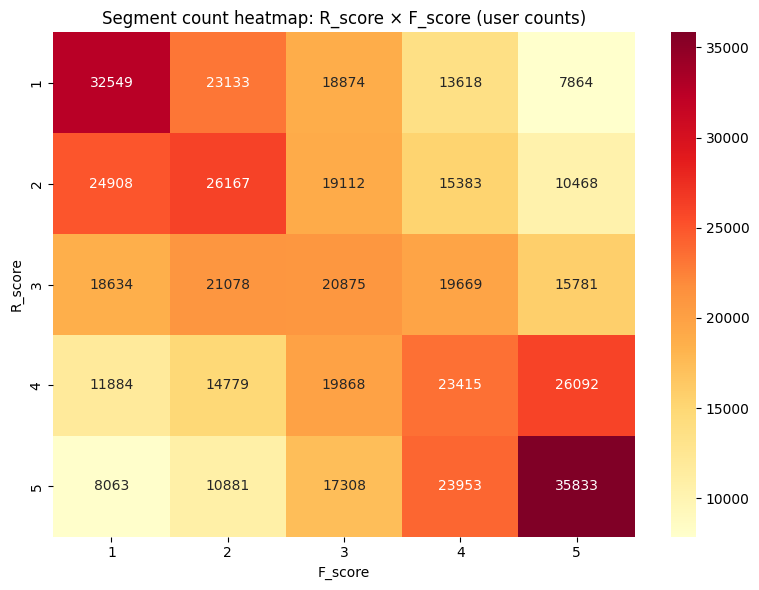

In [7]:
# 5.3.2 — Heatmap: user count in each (R_score × F_score) cell
heatmap_data = rfm.groupby(["R_score", "F_score"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Segment count heatmap: R_score × F_score (user counts)")
ax.set_xlabel("F_score"); ax.set_ylabel("R_score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rfm_heatmap_RF.png", dpi=150)
plt.show()

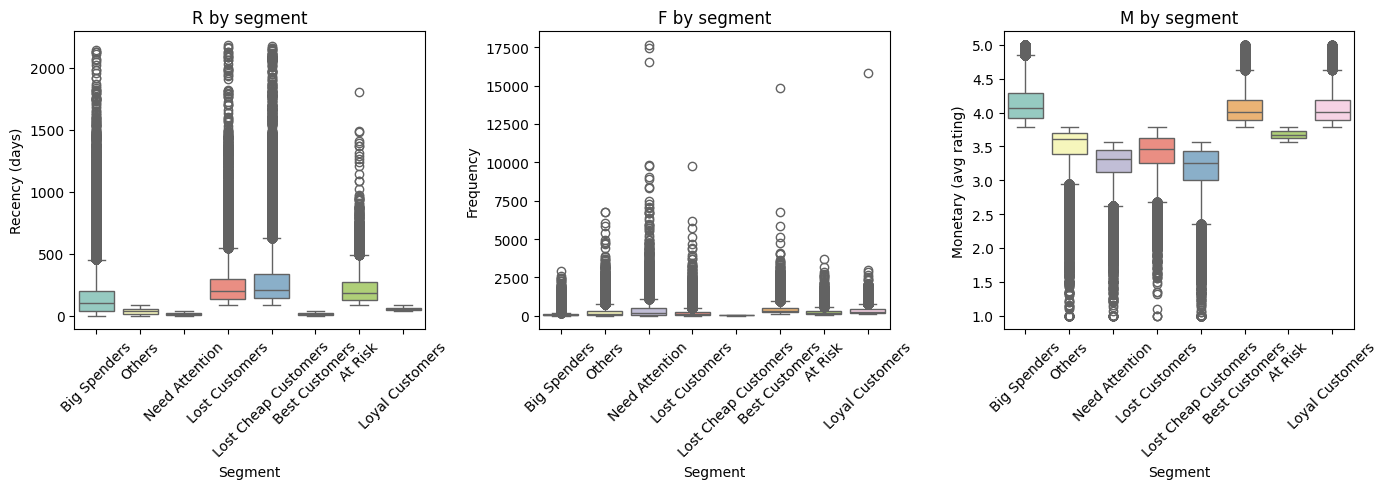

In [8]:
# 5.3.3 — Box plots: R, F, M by segment
order_seg = segment_counts.index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, ylabel in zip(axes, ["R", "F", "M"], ["Recency (days)", "Frequency", "Monetary (avg rating)"]):
    sns.boxplot(data=rfm, x="segment", y=col, order=order_seg, ax=ax, palette="Set3")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Segment")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_title("R by segment"); axes[1].set_title("F by segment"); axes[2].set_title("M by segment")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rfm_boxplot_by_segment.png", dpi=150)
plt.show()

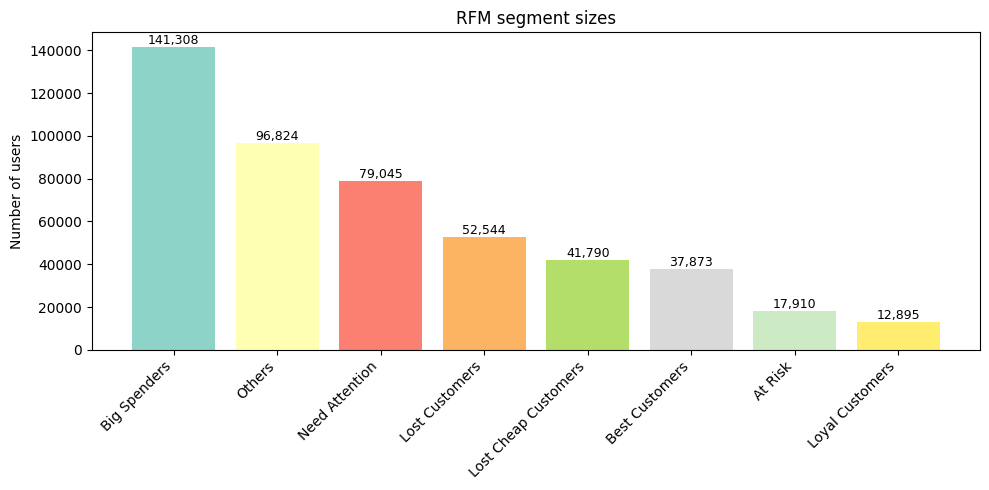

In [9]:
# 5.3.4 — Bar chart of segment sizes
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(segment_counts)), segment_counts.values, color=plt.cm.Set3(np.linspace(0, 1, len(segment_counts))))
ax.set_xticks(range(len(segment_counts)))
ax.set_xticklabels(segment_counts.index, rotation=45, ha="right")
ax.set_ylabel("Number of users")
ax.set_title("RFM segment sizes")
for i, v in enumerate(segment_counts.values):
    ax.text(i, v + max(segment_counts.values)*0.01, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rfm_segment_sizes.png", dpi=150)
plt.show()

In [10]:
# Optional: Treemap of segment sizes (Plotly; root "All" for valid hierarchy)
labels = ["All"] + segment_counts.index.tolist()
parents = [""] + ["All"] * len(segment_counts)
values = [0] + segment_counts.values.tolist()
fig_treemap = go.Figure(go.Treemap(labels=labels, parents=parents, values=values))
fig_treemap.update_layout(title="RFM segment sizes (treemap)")
fig_treemap.write_html(OUTPUT_DIR / "rfm_segment_treemap.html")
fig_treemap.show()

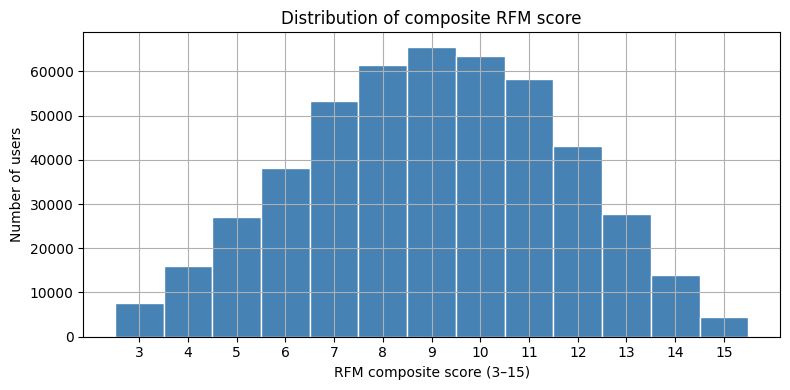

In [11]:
# 5.3.5 — Composite RFM score distribution (3–15)
fig, ax = plt.subplots(figsize=(8, 4))
rfm["RFM_score"].hist(bins=13, range=(2.5, 15.5), ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("RFM composite score (3–15)")
ax.set_ylabel("Number of users")
ax.set_title("Distribution of composite RFM score")
ax.set_xticks(range(3, 16))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rfm_score_distribution.png", dpi=150)
plt.show()

## Section 5.4 Business Insights and Strategic Implications

The goal of RFM segmentation is not only descriptive analysis but also **actionable decision making**. Each segment represents users with different engagement patterns and therefore requires different retention or marketing strategies.

We first summarize key statistics for each segment (mean R, F, M and population size). These summaries provide insight into how engagement differs across groups.

Based on these behavioral patterns, we propose **targeted strategies** aligned with standard CRM practices. The objective is to:

- **Retain high-value customers**
- **Increase engagement among loyal users**
- **Re-activate at-risk users**
- **Avoid overspending marketing resources on low-value segments**

In [12]:
# Segment-level summary (mean R, F, M and count) for insights
segment_summary = rfm.groupby("segment").agg(
    users=("CustomerID", "count"),
    R_avg=("R", "mean"),
    F_avg=("F", "mean"),
    M_avg=("M", "mean"),
).round(2)
segment_summary = segment_summary.reindex(order_seg)
display(segment_summary)

,users,R_avg,F_avg,M_avg
segment,,,,
Big Spenders,141308,144.68,87.11,4.14
Others,96824,38.33,246.28,3.50
Need Attention,79045,13.79,359.84,3.25
Lost Customers,52544,242.87,184.80,3.41
Lost Cheap Customers,41790,281.45,31.34,3.17
Best Customers,37873,12.91,422.63,4.06
At Risk,17910,215.43,244.09,3.68
Loyal Customers,12895,55.10,347.77,4.07


### Marketing Strategy by Segment (Aligned with Course Materials)

Based on the RFM segmentation results, we map each behavioral segment to potential engagement strategies inspired by the course materials. Because the Netflix dataset contains **user ratings rather than direct monetary transactions**, the recommended actions should be interpreted as **engagement strategies rather than pricing strategies**.

| Segment | Typical Behavioral Pattern | Suggested Strategy |
|--------|----------------------------|--------------------|
| **Best Customers** | Very recent activity, high frequency, and strong engagement. | Prioritize retention through loyalty mechanisms such as early access to new content, exclusive previews, or referral incentives. |
| **Loyal Customers** | High frequency with consistent engagement, though slightly less recent than top users. | Maintain satisfaction through personalized recommendations and occasional premium feature promotions. |
| **Big Spenders** | High monetary score (high average ratings) indicating strong positive engagement. | Promote premium or exclusive content likely to match their preferences. |
| **At Risk** | Previously active users whose recent engagement has declined. | Implement win-back campaigns such as personalized recommendations, “We miss you” notifications, or limited-time promotions. |
| **Lost Customers** | Users who have not interacted with the platform for a long period. | Consider re-engagement campaigns with stronger incentives; if engagement remains low, prioritize resources elsewhere. |
| **Lost Cheap Customers** | Very low historical engagement and low activity. | Apply minimal marketing investment; focus on low-cost outreach methods only. |
| **Potential Loyalists** | Recent users with moderate activity who may become highly engaged. | Encourage continued engagement through weekly recommendations, curated content lists, or nudges to rate more titles. |
| **Need Attention** | Moderate recency but low frequency or engagement. | Improve user experience through better recommendation quality and content discovery features. |
| **Hibernating** | Users with both low recency and low frequency. | Target with re-activation campaigns or reminders highlighting new content additions. |
| **Others** | Users who do not clearly fall into the above categories. | Apply general engagement strategies and test messaging through A/B experiments. |

### Retention Context (Course Insight)

Customer retention plays a crucial role in long-term platform growth. Marketing research commonly shows that **acquiring a new customer can cost up to five times more than retaining an existing one**. Therefore, segments such as **At Risk** and **Potential Loyalists** represent particularly valuable intervention points where targeted engagement strategies may prevent churn and increase long-term platform activity.

### 5.4.2 Comparison with Person D's Clustering Results

While RFM segmentation is **rule-based and interpretable**, clustering methods provide a **data-driven approach** to grouping users based on behavioral similarity.

Person D performed clustering using **K-Means on PCA-transformed user features**, including:

- rating_count
- rating_mean
- rating_std
- most_common_rating
- five_star_percentage
- rating_time_range

To evaluate consistency between the two approaches, we compare:

- **RFM segment labels**
- **Cluster assignments from Person D**

using a cross-tabulation matrix.

This comparison serves two purposes:

1. **Validation** – If clusters and RFM segments overlap significantly, this supports the robustness of both approaches.
2. **Behavioral nuance** – Disagreements may reveal subgroups with unique behavioral characteristics.

For example, some users may appear as **Best Customers under RFM** (recent and frequent engagement) but fall into a **Harsh Critics cluster** due to consistently low rating behavior. Such insights can guide **more personalized recommendation or communication strategies**.

In [13]:
# Load Person D's user clusters (index = CustomerID)
user_clusters_path = CLUSTERING_DIR / "user_clusters.parquet"
if user_clusters_path.exists():
    user_clusters = pd.read_parquet(user_clusters_path)
    if user_clusters.index.name == "CustomerID" or "CustomerID" not in user_clusters.columns:
        user_clusters = user_clusters.reset_index()
    if "CustomerID" not in user_clusters.columns and "index" in user_clusters.columns:
        user_clusters = user_clusters.rename(columns={"index": "CustomerID"})
    # Merge with our RFM segment
    rfm_with_cluster = rfm.merge(
        user_clusters[["CustomerID", "cluster_name"]].drop_duplicates(),
        on="CustomerID", how="left"
    )
    rfm_with_cluster["cluster_name"] = rfm_with_cluster["cluster_name"].fillna("(not in 04)")
    cross = pd.crosstab(rfm_with_cluster["segment"], rfm_with_cluster["cluster_name"], margins=True)
    print("Cross-tabulation: RFM segment (rows) × Person D cluster (columns)")
    display(cross)
else:
    print("Person D output not found at", user_clusters_path, "- run 04_clustering first.")

Cross-tabulation: RFM segment (rows) × Person D cluster (columns)


cluster_name,Casual Users,Power Users,All
segment,,,
At Risk,14550,3360,17910
Best Customers,11927,25946,37873
Big Spenders,21343,119965,141308
Lost Cheap Customers,37986,3804,41790
Lost Customers,45357,7187,52544
Loyal Customers,3564,9331,12895
Need Attention,75391,3654,79045
Others,82830,13994,96824
All,292948,187241,480189


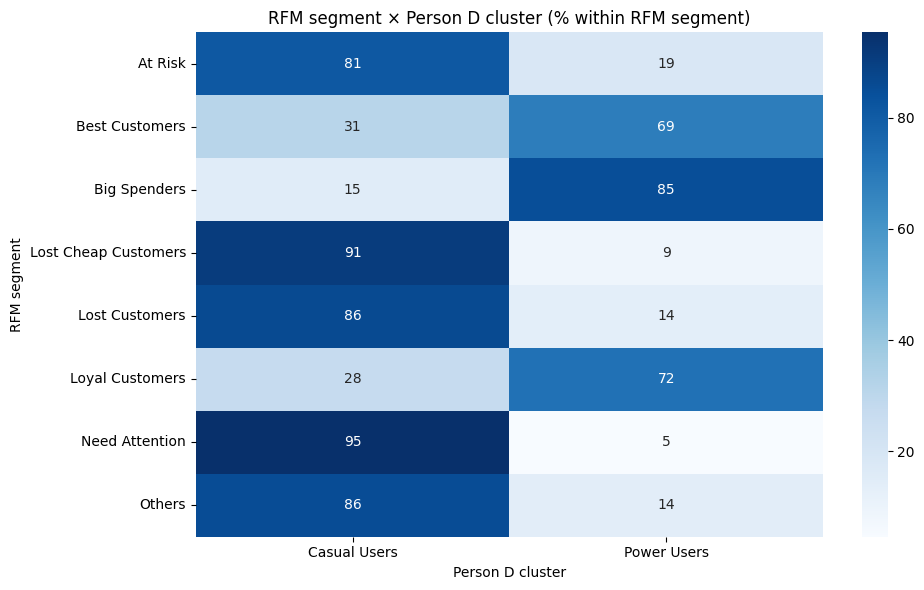

In [14]:
# Heatmap of cross-tabulation (normalize by row to see cluster mix within each RFM segment)
if user_clusters_path.exists():
    cross_pct = cross.div(cross.iloc[:, :-1].sum(axis=1), axis=0).iloc[:-1, :-1] * 100
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(cross_pct, annot=True, fmt=".0f", cmap="Blues", ax=ax)
    ax.set_title("RFM segment × Person D cluster (% within RFM segment)")
    ax.set_xlabel("Person D cluster"); ax.set_ylabel("RFM segment")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "rfm_vs_clustering_heatmap.png", dpi=150)
    plt.show()

**Interpretation:** RFM segments are based on *recency, frequency, and average rating*; Person D's clusters are based on *PCA of user features* (rating_count, rating_mean, rating_std, most_common_rating, five_star_pct, date_range_days). Some overlap is expected (e.g. Best Customers with Power Users / Generous Raters). Differences highlight users who are "recent & high value" (RFM) but fall into a different behavioral cluster (e.g. Harsh Critics by rating style), useful for tailored messaging — consistent with the course idea of combining RFM with clustering to target groups.

In [15]:
# Save RFM results for downstream use (e.g. presentation, integration)
rfm.to_parquet(OUTPUT_DIR / "rfm_segments.parquet", index=False)
print("Saved:", OUTPUT_DIR / "rfm_segments.parquet")
print("All outputs:", [p.name for p in sorted(OUTPUT_DIR.glob("*"))])

Saved: /Users/yuanyuanxie/Desktop/DeepLearning/netflix-prize-data-mining-project/outputs/05_rfm_analysis/rfm_segments.parquet
All outputs: ['rfm_3d_scatter.html', 'rfm_boxplot_by_segment.png', 'rfm_heatmap_RF.png', 'rfm_score_distribution.png', 'rfm_segment_sizes.png', 'rfm_segment_treemap.html', 'rfm_segments.parquet', 'rfm_vs_clustering_heatmap.png']


## Key Takeaways

- **RFM segmentation provides a simple yet powerful framework** for understanding user engagement patterns. By combining recency, frequency, and monetary signals, we can identify high-value customers as well as disengaged users.

- **Rule-based RFM segments complement data-driven clustering methods.** While RFM emphasizes behavioral recency and activity level, clustering captures more nuanced patterns such as rating variability and sentiment.

- **Combining segmentation approaches can improve targeting strategies.** For example, a user classified as a "Best Customer" by RFM but identified as a "Harsh Critic" by clustering may require a different engagement strategy than a consistently positive reviewer.

- **Future work** could extend this analysis by:
  - Using a **rolling reference date** to track changes in user engagement over time.
  - Integrating **recommendation system outputs** (Person C) to personalize interventions by segment.
  - Monitoring segment transitions to identify early warning signals of customer churn.